Link Google Colab: https://colab.research.google.com/drive/1oaH9EYDP6mqyWEmjdEz4KklH8YV3Lrme?authuser=2#scrollTo=3w64tPOW84eU

# Modeling Machine Learning (Klasifikasi Spoiler Review Buku Goodreads)

Dataset ini digunakan untuk melatih dan mengevaluasi model Machine Learning dalam mendeteksi spoiler pada review buku Goodreads berbahasa Indonesia.

**Input:**
review_preprocessed.csv

File ini merupakan hasil preprocessing yang telah melalui tahap pembersihan dan normalisasi teks.

Kolom yang digunakan:
- review_text_stem
Teks yang telah melalui stopword removal dan stemming, digunakan sebagai fitur untuk model Machine Learning.
- spoiler_label
Label biner: 1 untuk spoiler, 0 untuk non-spoiler.

**Output:**
model_evaluation_results

Hasil berupa performa model klasifikasi yang mencakup metrik evaluasi serta perbandingan antar model.
Model yang digunakan:
- Support Vector Machine (SVM) dengan kernel linear
- Random Forest
- XGBoost

Tahapan:
1. Setup Environment
2. Load Data
3. TF-IDF Vectorization
4. Train-Test Split
5. Setup Fungsi Evaluasi Model
6. Training & Evaluasi Model (SVM, Random Forest, XGBoost)
7. Perbandingan Model
8. Kesimpulan dan Analisis

## 1. Setup Environment
a. install dependency

In [6]:
# install semua dependensi yang dibutuhkan
# xgboost  : implementasi gradient boosting yang dioptimasi
# imbalanced-learn : library untuk handling imbalanced data (scikit-learn ecosystem)
# scikit-learn sudah include SVM dan Random Forest

!pip install scikit-learn xgboost imbalanced-learn pandas numpy matplotlib seaborn

b. Import Library & Konfigurasi

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/NLP_Kelompok3/review_preprocessed.csv')

warnings.filterwarnings("ignore")

# konfigurasi path
INPUT_CSV = '/content/drive/MyDrive/Colab Notebooks/NLP_Kelompok3/review_preprocessed.csv'
df = pd.read_csv(INPUT_CSV, encoding='utf-8-sig')
RANDOM_SEED = 42        # seed untuk reproducibility
TEST_SIZE   = 0.2       # 80% train, 20% test

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load & Eksplorasi Data

Memuat data dan melihat kondisi awal dataset, termasuk jumlah data dan distribusi label. Informasi ini digunakan untuk memahami tingkat imbalance yang akan memengaruhi proses modeling.

In [8]:
# load data hasil preprocessing
df = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")

print(f"total baris    : {len(df)}")
print(f"total kolom    : {len(df.columns)}")
print(f"kolom          : {list(df.columns)}")

# cek missing value pada kolom yang akan dipakai
print("\nMissing values pada kolom yang dipakai")
print(df[["review_text_stem", "spoiler_label"]].isnull().sum())

# hapus baris yang kolom utamanya kosong
df = df.dropna(subset=["review_text_stem", "spoiler_label"]).reset_index(drop=True)
print(f"\nSetelah drop missing: {len(df)} baris")

total baris    : 8694
total kolom    : 3
kolom          : ['review_text_clean', 'review_text_stem', 'spoiler_label']

Missing values pada kolom yang dipakai
review_text_stem    0
spoiler_label       0
dtype: int64

Setelah drop missing: 8694 baris


In [9]:
# distribusi label dan perhitungan imbalance ratio
label_counts = df["spoiler_label"].value_counts()
label_pct    = df["spoiler_label"].value_counts(normalize=True) * 100

print("Distribusi Label")
dist_df = pd.DataFrame({
    "jumlah" : label_counts,
    "persen" : label_pct.round(2)
}).rename(index={0: "non-spoiler (0)", 1: "spoiler (1)"})
print(dist_df)

# hitung imbalance ratio angka yg dipake sebagai scale_pos_weight di XGBoost
n_nonspoiler = label_counts[0]
n_spoiler    = label_counts[1]
imbalance_ratio = n_nonspoiler / n_spoiler
print(f"\nimbalance ratio (non-spoiler / spoiler) : {imbalance_ratio:.2f}")
print(f"artinya: untuk setiap 1 spoiler, ada {imbalance_ratio:.1f} non-spoiler")

Distribusi Label
                 jumlah  persen
spoiler_label                  
non-spoiler (0)    7943   91.36
spoiler (1)         751    8.64

imbalance ratio (non-spoiler / spoiler) : 10.58
artinya: untuk setiap 1 spoiler, ada 10.6 non-spoiler


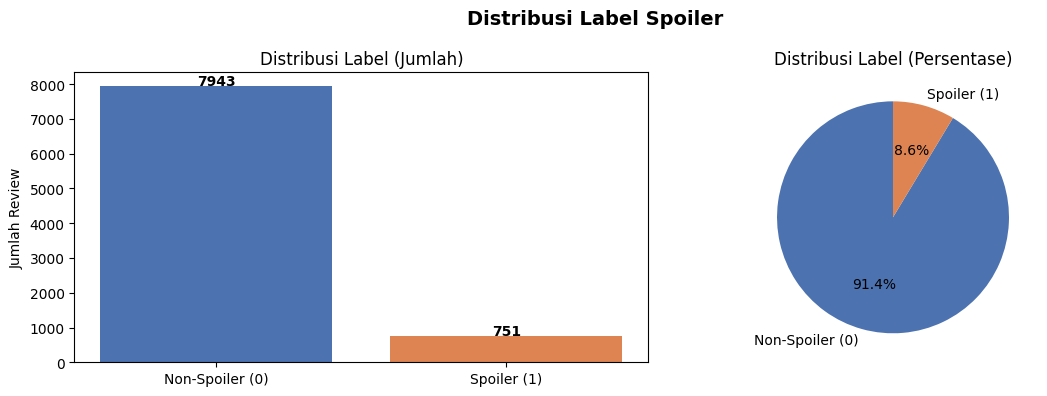

In [10]:
# visualisasi distribusi label
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# bar chart jumlah
colors = ["#4C72B0", "#DD8452"]
axes[0].bar(["Non-Spoiler (0)", "Spoiler (1)"], [n_nonspoiler, n_spoiler], color=colors)
axes[0].set_title("Distribusi Label (Jumlah)")
axes[0].set_ylabel("Jumlah Review")
for i, v in enumerate([n_nonspoiler, n_spoiler]):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# pie chart persentase
axes[1].pie(
    [n_nonspoiler, n_spoiler],
    labels=["Non-Spoiler (0)", "Spoiler (1)"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=90
)
axes[1].set_title("Distribusi Label (Persentase)")

plt.suptitle("Distribusi Label Spoiler", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("distribusi_label.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# statistik panjang teks per label
# panjang teks bisa jadi sinyal — spoiler mungkin cenderung lebih panjang
df["text_len"] = df["review_text_stem"].apply(lambda x: len(str(x).split()))

print("Statistik panjang teks (jumlah token) per label")
print(df.groupby("spoiler_label")["text_len"].describe().round(2).rename(index={0: "non-spoiler", 1: "spoiler"}))

Statistik panjang teks (jumlah token) per label
                count   mean    std  min   25%   50%    75%     max
spoiler_label                                                      
non-spoiler    7943.0  63.32  71.43  1.0  18.0  40.0   83.0  1149.0
spoiler         751.0  83.50  83.45  2.0  30.5  59.0  117.0   874.0


## 3. TF-IDF Vectorization

Mengubah teks menjadi representasi numerik menggunakan TF-IDF agar dapat diproses oleh model Machine Learning.

Menggunakan review_text_stem untuk mengurangi variasi kata dan dimensi fitur, sehingga representasi lebih efisien dan tidak terlalu sparse.

Parameter ngram_range (1, 2) digunakan untuk menangkap kata tunggal dan pasangan kata, karena kombinasi kata dapat memberikan sinyal yang lebih kuat dalam mendeteksi spoiler.

Jumlah fitur dibatasi (max_features) untuk mengurangi noise dan menjaga efisiensi model.

In [12]:
# persiapan data
X = df["review_text_stem"].astype(str)
y = df["spoiler_label"].astype(int)

print(f"jumlah sampel  : {len(X)}")
print(f"distribusi y   : {dict(y.value_counts().sort_index())}")

jumlah sampel  : 8694
distribusi y   : {0: np.int64(7943), 1: np.int64(751)}


## 4. Train-Test Split (Stratified)

Membagi data menjadi train dan test menggunakan stratified split untuk menjaga proporsi label tetap konsisten. Hal ini penting agar distribusi spoiler dan non-spoiler pada data training dan testing tetap seimbang, sehingga hasil evaluasi model lebih representatif.

In [13]:
# bagi data jadi train dan test
# stratify=y biar proporsi label spoiler dan non-spoiler tetap sama
# jadi distribusinya ga berubah setelah di-split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"train set : {len(X_train_raw)} sampel")
print(f"test set  : {len(X_test_raw)} sampel")

# verifikasi proporsi label
print("\nProporsi label di train set")
print(y_train.value_counts(normalize=True).round(4))

# cek jumlah data di masing-masing label di test set
print("\nProporsi label di test set")
print(y_test.value_counts(normalize=True).round(4))

# ini buat mastiin stratified split berhasil
# harusnya proporsi train dan test mirip banget
print("\nProporsi label sama di train dan test, stratified split berhasil")

train set : 6955 sampel
test set  : 1739 sampel

Proporsi label di train set
spoiler_label
0    0.9136
1    0.0864
Name: proportion, dtype: float64

Proporsi label di test set
spoiler_label
0    0.9137
1    0.0863
Name: proportion, dtype: float64

Proporsi label sama di train dan test, stratified split berhasil


In [14]:
# inisialisasi TF-IDF untuk ubah teks jadi angka
# max_features=50000 -> biar fitur ga kebanyakan (ambil 50k kata paling penting)
# ngram_range=(1,2) -> pakai unigram + bigram biar konteks kata lebih kebaca
# min_df=2 -> kata yang cuma muncul 1x diabaikan (noise)
# sublinear_tf=True -> biar kata yang sering banget ga terlalu dominan

vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

# fit cuma di train biar ga ada data leakage
# jadi vocab cuma belajar dari data train aja
X_train = vectorizer.fit_transform(X_train_raw)

# test cuma transform pakai vocab dari train
# jadi model ga "lihat" data test saat training
X_test  = vectorizer.transform(X_test_raw)

print(f"dimensi X_train : {X_train.shape}")
print(f"dimensi X_test  : {X_test.shape}")
print(f"\nartiya: {X_train.shape[0]} dokumen train, {X_train.shape[1]} fitur unik")

dimensi X_train : (6955, 50000)
dimensi X_test  : (1739, 50000)

artiya: 6955 dokumen train, 50000 fitur unik


## 5. Setup Fungsi Evaluasi Model
Evaluasi model dilakukan untuk mengukur performa model dalam mengklasifikasikan data secara lebih akurat, terutama pada kondisi dataset yang tidak seimbang (imbalanced). Karena accuracy saja tidak cukup merepresentasikan performa, digunakan beberapa metrik evaluasi tambahan.

Metrik yang digunakan meliputi:
- Precision, Recall, dan F1-Score untuk menilai performa pada kelas spoiler
- AUC-ROC untuk mengukur kemampuan model membedakan dua kelas secara keseluruhan
- Confusion Matrix untuk melihat jenis kesalahan prediksi

AUC-ROC digunakan sebagai metrik utama karena tidak bergantung pada threshold dan lebih stabil pada data yang tidak seimbang.

In [15]:
def evaluate_model(model_name, y_true, y_pred, y_score):
    """
    menghitung dan mencetak semua metrik evaluasi yang relevan.
    y_score : probabilitas kelas positif (spoiler) atau decision function score.
              dipakai untuk menghitung AUC-ROC.
    """

    print(f"  HASIL EVALUASI — {model_name}")

    # classification report: precision, recall, f1 per kelas + macro avg
    print("\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=["non-spoiler (0)", "spoiler (1)"],
        digits=4
    ))

    # AUC-ROC
    auc = roc_auc_score(y_true, y_score)
    print(f"AUC-ROC : {auc:.4f}")

    return {
        "model"         : model_name,
        "precision_0"   : precision_score(y_true, y_pred, pos_label=0),
        "precision_1"   : precision_score(y_true, y_pred, pos_label=1),
        "recall_0"      : recall_score(y_true, y_pred, pos_label=0),
        "recall_1"      : recall_score(y_true, y_pred, pos_label=1),
        "f1_0"          : f1_score(y_true, y_pred, pos_label=0),
        "f1_1"          : f1_score(y_true, y_pred, pos_label=1),
        "f1_macro"      : f1_score(y_true, y_pred, average="macro"),
        "auc_roc"       : auc,
    }


def plot_confusion_matrix(model_name, y_true, y_pred, ax):
    """plot confusion matrix ke subplot ax yang diberikan."""
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["non-spoiler", "spoiler"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(model_name, fontweight="bold")


# dict untuk menyimpan hasil semua model ini dipakai di bagian perbandingan akhir
results = {}
predictions = {}

## 6. Training Model & Evaluasi (SVM, Random Forest, XGBoost)

## a. Model SVM

Pada tahap ini dilakukan proses pelatihan model SVM sekaligus pencarian hyperparameter terbaik menggunakan cross-validation.

Hal yang dilakukan:
- Menggunakan Stratified K-Fold Cross Validation (5-fold) untuk memastikan setiap fold memiliki distribusi kelas yang seimbang
- Mendefinisikan model dasar LinearSVC dengan class_weight='balanced' untuk menangani data imbalanced
- Melakukan hyperparameter tuning pada parameter C untuk mencari nilai terbaik yang mengontrol keseimbangan antara underfitting dan overfitting
- Menggunakan GridSearchCV untuk melatih model pada beberapa kombinasi parameter dan memilih model terbaik berdasarkan skor AUC-ROC
- Menggunakan semua core CPU (n_jobs=-1) untuk mempercepat proses komputasi

Hasil dari proses ini adalah model SVM terbaik (best_estimator_) beserta parameter optimalnya yang akan digunakan pada tahap evaluasi di data test.

In [16]:
# stratified k-fold untuk cross-validation
# shuffle=True memastikan pembagian fold acak tapi reprodukibel (random_state)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# SVM
print("tuning SVM...")
t0 = time.time()

svm_params = {
    "C": [0.01, 0.1, 1, 10]
}

svm_base = LinearSVC(
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_SEED
)

svm_grid = GridSearchCV(
    svm_base,
    svm_params,
    cv=cv,
    scoring="roc_auc",   # optimasi berdasarkan AUC, bukan accuracy
    n_jobs=-1,           # pakai semua CPU core
    verbose=1
)
svm_grid.fit(X_train, y_train)

print(f"\nwaktu tuning  : {time.time() - t0:.1f} detik")
print(f"parameter terbaik : {svm_grid.best_params_}")
print(f"AUC-ROC CV terbaik: {svm_grid.best_score_:.4f}")

tuning SVM...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

waktu tuning  : 9.7 detik
parameter terbaik : {'C': 0.01}
AUC-ROC CV terbaik: 0.7265


In [17]:
# evaluasi SVM di test set
best_svm = svm_grid.best_estimator_

svm_pred  = best_svm.predict(X_test)
# LinearSVC tidak punya predict_proba — pakai decision_function sebagai pengganti
# decision_function menghasilkan skor jarak ke hyperplane (bukan probabilitas)
# tapi cukup valid untuk menghitung AUC karena AUC hanya butuh ranking, bukan probabilitas absolut
svm_score = best_svm.decision_function(X_test)

results["SVM"] = evaluate_model("SVM (Linear)", y_test, svm_pred, svm_score)
predictions["SVM"] = svm_pred

  HASIL EVALUASI — SVM (Linear)

Classification Report:
                 precision    recall  f1-score   support

non-spoiler (0)     0.9404    0.8143    0.8728      1589
    spoiler (1)     0.1873    0.4533    0.2651       150

       accuracy                         0.7832      1739
      macro avg     0.5639    0.6338    0.5690      1739
   weighted avg     0.8754    0.7832    0.8204      1739

AUC-ROC : 0.7263


## b. Model Random Forest

Pada tahap ini dilakukan proses pelatihan dan evaluasi model Random Forest sebagai metode ensemble untuk klasifikasi.

Hal yang dilakukan:
- Melakukan training model Random Forest dengan beberapa Decision Tree yang digabungkan untuk menghasilkan prediksi yang lebih stabil
- Melakukan hyperparameter tuning menggunakan GridSearchCV untuk mencari kombinasi terbaik dari jumlah tree (n_estimators), kedalaman tree (max_depth), dan jumlah fitur yang dipertimbangkan (max_features)
- Menggunakan class_weight='balanced' untuk mengatasi ketidakseimbangan data
- Menggunakan Stratified K-Fold Cross Validation (5-fold) untuk memilih model terbaik berdasarkan AUC-ROC
- Setelah model terbaik diperoleh, dilakukan prediksi pada data test untuk mengevaluasi performa akhir menggunakan berbagai metrik evaluasi

In [18]:
# mulai proses tuning Random Forest
# ini biasanya agak lama jadi di-print biar tahu lagi jalan
print("tuning Random Forest...")
t0 = time.time()

rf_params = {
    "n_estimators" : [100, 200],
    "max_depth"    : [None, 20, 40],
    "max_features" : ["sqrt"]
}

# model dasar Random Forest
rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

# GridSearch untuk cari kombinasi parameter terbaik
rf_grid = GridSearchCV(
    rf_base,
    rf_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)
# mulai training + tuning model
rf_grid.fit(X_train, y_train)

print(f"\nwaktu tuning  : {time.time() - t0:.1f} detik")
print(f"parameter terbaik : {rf_grid.best_params_}")
print(f"AUC-ROC CV terbaik: {rf_grid.best_score_:.4f}")

tuning Random Forest...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

waktu tuning  : 331.6 detik
parameter terbaik : {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
AUC-ROC CV terbaik: 0.6966


In [19]:
# evaluasi Random Forest di test set
best_rf = rf_grid.best_estimator_

rf_pred  = best_rf.predict(X_test)
# Random Forest punya predict_proba — ambil probabilitas kelas positif (kolom 1)
rf_score = best_rf.predict_proba(X_test)[:, 1]

results["RF"] = evaluate_model("Random Forest", y_test, rf_pred, rf_score)
predictions["RF"] = rf_pred

  HASIL EVALUASI — Random Forest

Classification Report:
                 precision    recall  f1-score   support

non-spoiler (0)     0.9137    1.0000    0.9549      1589
    spoiler (1)     0.0000    0.0000    0.0000       150

       accuracy                         0.9137      1739
      macro avg     0.4569    0.5000    0.4775      1739
   weighted avg     0.8349    0.9137    0.8726      1739

AUC-ROC : 0.6946


## c. Model XGBoost

Pada tahap ini dilakukan pembangunan dan evaluasi model XGBoost sebagai metode gradient boosting untuk meningkatkan performa klasifikasi secara bertahap.

Hal yang dilakukan:
- Melakukan training model XGBoost yang bekerja dengan memperbaiki kesalahan prediksi secara sekuensial antar tree
- Melakukan hyperparameter tuning untuk mencari kombinasi terbaik dari max_depth, learning_rate, n_estimators, dan subsample
- Menggunakan scale_pos_weight untuk menangani ketidakseimbangan data dengan memberi bobot lebih pada kelas minoritas (spoiler)
- Menggunakan Stratified K-Fold Cross Validation (5-fold) untuk memilih model terbaik berdasarkan AUC-ROC
- Mengoptimalkan parameter grid agar proses training tetap efisien secara komputasi
- Melakukan evaluasi akhir pada data test untuk mengukur performa model menggunakan metrik evaluasi

In [20]:
# mulai tuning XGBoost
print("tuning XGBoost...")
t0 = time.time()

# parameter yang mau dicoba
xgb_params = {
    "n_estimators"  : [100, 200],
    "max_depth"     : [3, 6],
    "learning_rate" : [0.05, 0.1],
    "subsample"     : [0.8]
}

# model dasar XGBoost
xgb_base = XGBClassifier(
    scale_pos_weight=imbalance_ratio,  # handling imbalance — nilai dari rasio yang dihitung di bagian 2
    eval_metric="auc",
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbosity=0
)

# GridSearch untuk cari kombinasi parameter terbaik
xgb_grid = GridSearchCV(
    xgb_base,
    xgb_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# mulai training + tuning
xgb_grid.fit(X_train, y_train)

print(f"\nwaktu tuning  : {time.time() - t0:.1f} detik")
print(f"parameter terbaik : {xgb_grid.best_params_}")
print(f"AUC-ROC CV terbaik: {xgb_grid.best_score_:.4f}")

tuning XGBoost...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

waktu tuning  : 1058.0 detik
parameter terbaik : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
AUC-ROC CV terbaik: 0.6793


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
# evaluasi XGBoost di test set
best_xgb = xgb_grid.best_estimator_

xgb_pred  = best_xgb.predict(X_test)
xgb_score = best_xgb.predict_proba(X_test)[:, 1]

results["XGBoost"] = evaluate_model("XGBoost", y_test, xgb_pred, xgb_score)
predictions["XGBoost"] = xgb_pred

  HASIL EVALUASI — XGBoost

Classification Report:
                 precision    recall  f1-score   support

non-spoiler (0)     0.9328    0.7955    0.8587      1589
    spoiler (1)     0.1536    0.3933    0.2210       150

       accuracy                         0.7608      1739
      macro avg     0.5432    0.5944    0.5398      1739
   weighted avg     0.8656    0.7608    0.8037      1739

AUC-ROC : 0.6709


## 7. Perbandingan Ketiga Model

Bagian ini menyajikan perbandingan performa ketiga model dalam bentuk tabel dan visualisasi.

Perbandingan difokuskan pada:
- AUC-ROC sebagai metrik utama untuk mengukur kemampuan diskriminasi model
- F1-score kelas spoiler (1) sebagai indikator utama keberhasilan deteksi spoiler
- Confusion matrix untuk menganalisis pola kesalahan dari masing-masing model

In [23]:
# tabel perbandingan metrik semua model
comparison_df = pd.DataFrame(results).T

# format agar lebih mudah dibaca
display_cols = [
    "model", "auc_roc",
    "f1_macro", "f1_0", "f1_1",
    "precision_0", "precision_1",
    "recall_0", "recall_1"
]

comparison_display = comparison_df[display_cols].copy()
comparison_display.columns = [
    "model", "AUC-ROC",
    "F1 Macro", "F1 Non-Spoiler", "F1 Spoiler",
    "Prec Non-Spoiler", "Prec Spoiler",
    "Recall Non-Spoiler", "Recall Spoiler"
]

numeric_cols = comparison_display.columns.drop("model")
comparison_display[numeric_cols] = comparison_display[numeric_cols].astype(float).round(4)

print("\nTABEL PERBANDINGAN METRIK SEMUA MODEL")
print()
print(comparison_display.to_string(index=False))


TABEL PERBANDINGAN METRIK SEMUA MODEL

        model  AUC-ROC  F1 Macro  F1 Non-Spoiler  F1 Spoiler  Prec Non-Spoiler  Prec Spoiler  Recall Non-Spoiler  Recall Spoiler
 SVM (Linear)   0.7263    0.5690          0.8728      0.2651            0.9404        0.1873              0.8143          0.4533
Random Forest   0.6946    0.4775          0.9549      0.0000            0.9137        0.0000              1.0000          0.0000
      XGBoost   0.6709    0.5398          0.8587      0.2210            0.9328        0.1536              0.7955          0.3933


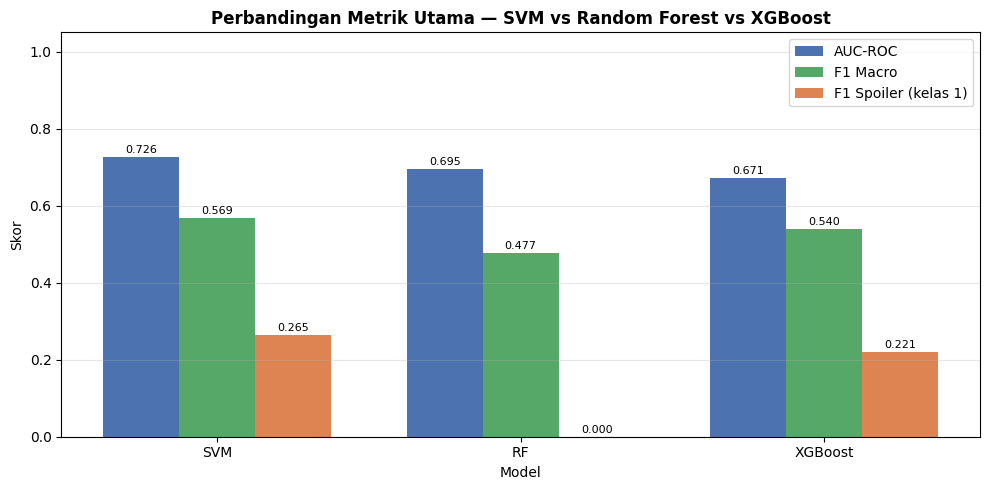

In [24]:
# visualisasi 1: bar chart perbandingan metrik utama
model_names  = list(results.keys())
auc_values   = [results[m]["auc_roc"] for m in model_names]
f1_macro     = [results[m]["f1_macro"] for m in model_names]
f1_spoiler   = [results[m]["f1_1"] for m in model_names]

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width, auc_values, width, label="AUC-ROC", color="#4C72B0")
bars2 = ax.bar(x,         f1_macro,   width, label="F1 Macro", color="#55A868")
bars3 = ax.bar(x + width, f1_spoiler, width, label="F1 Spoiler (kelas 1)", color="#DD8452")

ax.set_xlabel("Model")
ax.set_ylabel("Skor")
ax.set_title("Perbandingan Metrik Utama — SVM vs Random Forest vs XGBoost", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# tampilkan nilai di atas bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f"{h:.3f}",
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("perbandingan_metrik.png", dpi=150, bbox_inches="tight")
plt.show()

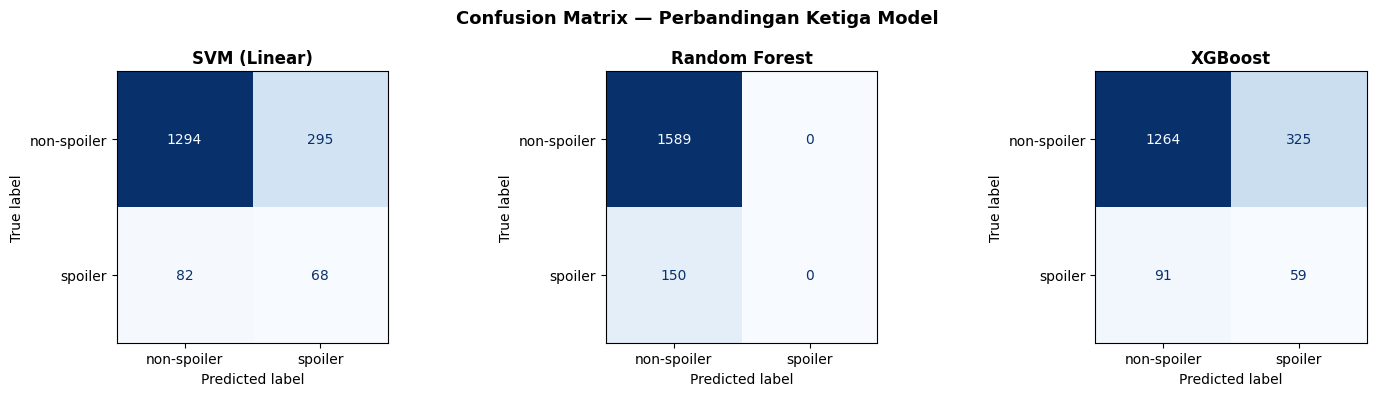


cara membaca confusion matrix:
- baris = label aktual (ground truth)
- kolom = label prediksi model

- atas kiri  (TN) : non-spoiler diprediksi non-spoiler — benar
- atas kanan (FP) : non-spoiler diprediksi spoiler     — salah (false alarm)
- bawah kiri (FN) : spoiler diprediksi non-spoiler     — salah (spoiler lolos deteksi)
- bawah kanan(TP) : spoiler diprediksi spoiler         — benar

FN (spoiler yang lolos) lebih berbahaya dari FP, model dengan recall spoiler tinggi = lebih sedikit FN.



In [25]:
# visualisasi 2: confusion matrix ketiga model side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_pred_pairs = [
    ("SVM (Linear)",  predictions["SVM"]),
    ("Random Forest", predictions["RF"]),
    ("XGBoost",       predictions["XGBoost"]),
]

for ax, (name, pred) in zip(axes, model_pred_pairs):
    plot_confusion_matrix(name, y_test, pred, ax)

plt.suptitle("Confusion Matrix — Perbandingan Ketiga Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_all.png", dpi=150, bbox_inches="tight")
plt.show()

# penjelasan baca confusion matrix
print("""
cara membaca confusion matrix:
- baris = label aktual (ground truth)
- kolom = label prediksi model

- atas kiri  (TN) : non-spoiler diprediksi non-spoiler — benar
- atas kanan (FP) : non-spoiler diprediksi spoiler     — salah (false alarm)
- bawah kiri (FN) : spoiler diprediksi non-spoiler     — salah (spoiler lolos deteksi)
- bawah kanan(TP) : spoiler diprediksi spoiler         — benar

FN (spoiler yang lolos) lebih berbahaya dari FP, model dengan recall spoiler tinggi = lebih sedikit FN.
""")

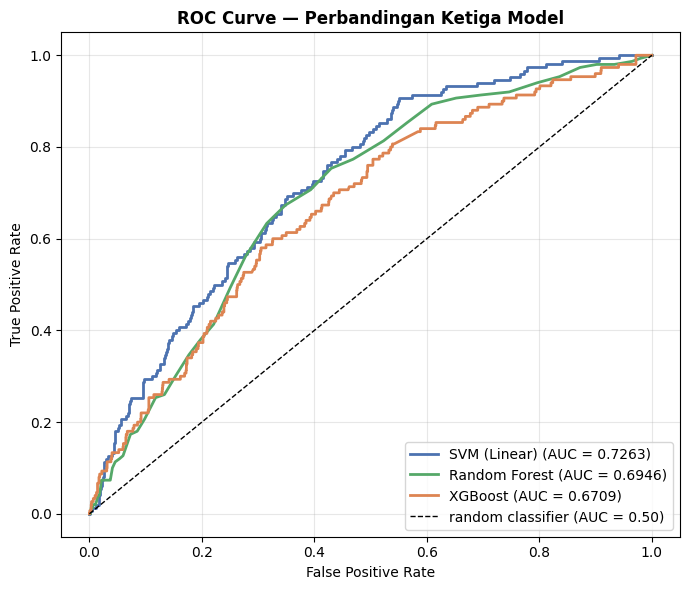


cara membaca ROC curve:
- sumbu x (FPR) : proporsi non-spoiler yang salah diprediksi spoiler
- sumbu y (TPR) : proporsi spoiler yang berhasil terdeteksi (= recall kelas 1)
- semakin kurva 'mendekati pojok kiri atas', semakin baik model
- garis putus-putus = random classifier (tidak berguna sama sekali)
- AUC = luas di bawah kurva. semakin mendekati 1.0, semakin baik



In [26]:
# visualisasi 3: ROC curve ketiga model
from sklearn.metrics import roc_curve

# kumpulkan skor probabilitas/decision function semua model
all_scores = {
    "SVM (Linear)"  : best_svm.decision_function(X_test),
    "Random Forest" : best_rf.predict_proba(X_test)[:, 1],
    "XGBoost"       : best_xgb.predict_proba(X_test)[:, 1],
}

fig, ax = plt.subplots(figsize=(7, 6))
colors_roc = ["#4C72B0", "#55A868", "#DD8452"]

for (name, score), color in zip(all_scores.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})", color=color, lw=2)

ax.plot([0, 1], [0, 1], "k--", lw=1, label="random classifier (AUC = 0.50)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Perbandingan Ketiga Model", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curve_all.png", dpi=150, bbox_inches="tight")
plt.show()

print("""
cara membaca ROC curve:
- sumbu x (FPR) : proporsi non-spoiler yang salah diprediksi spoiler
- sumbu y (TPR) : proporsi spoiler yang berhasil terdeteksi (= recall kelas 1)
- semakin kurva 'mendekati pojok kiri atas', semakin baik model
- garis putus-putus = random classifier (tidak berguna sama sekali)
- AUC = luas di bawah kurva. semakin mendekati 1.0, semakin baik
""")

## 8. Kesimpulan dan Analisis

Bagian ini merangkum temuan dari ketiga model dan memberikan rekomendasi berdasarkan hasil evaluasi.

In [27]:
# ringkasan otomatis berdasarkan hasil evaluasi
best_auc_model  = max(results, key=lambda m: results[m]["auc_roc"])
best_f1_model   = max(results, key=lambda m: results[m]["f1_1"])
best_rec_model  = max(results, key=lambda m: results[m]["recall_1"])


print("Ringkasan Hasil")
print(f"\nmodel terbaik berdasarkan AUC-ROC  : {best_auc_model} ({results[best_auc_model]['auc_roc']:.4f})")
print(f"model terbaik berdasarkan F1 spoiler: {best_f1_model} ({results[best_f1_model]['f1_1']:.4f})")
print(f"model terbaik berdasarkan recall spoiler: {best_rec_model} ({results[best_rec_model]['recall_1']:.4f})")

print("\nPerbandingan Final ---")
for model, r in results.items():
    print(f"\n{model}:")
    print(f"  AUC-ROC       : {r['auc_roc']:.4f}")
    print(f"  F1 spoiler    : {r['f1_1']:.4f}")
    print(f"  Recall spoiler: {r['recall_1']:.4f}")
    print(f"  F1 macro      : {r['f1_macro']:.4f}")

Ringkasan Hasil

model terbaik berdasarkan AUC-ROC  : SVM (0.7263)
model terbaik berdasarkan F1 spoiler: SVM (0.2651)
model terbaik berdasarkan recall spoiler: SVM (0.4533)

Perbandingan Final ---

SVM:
  AUC-ROC       : 0.7263
  F1 spoiler    : 0.2651
  Recall spoiler: 0.4533
  F1 macro      : 0.5690

RF:
  AUC-ROC       : 0.6946
  F1 spoiler    : 0.0000
  Recall spoiler: 0.0000
  F1 macro      : 0.4775

XGBoost:
  AUC-ROC       : 0.6709
  F1 spoiler    : 0.2210
  Recall spoiler: 0.3933
  F1 macro      : 0.5398
